# Outlier Analysis

### Importing Data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

high_value_df = pd.read_csv('../data/processed/high_value_outliers.csv')
high_frequency_df = pd.read_csv('../data/processed/high_freq_outliers.csv')

In [21]:
high_frequency_df.set_index('CustomerID', inplace=True)
high_value_df.set_index('CustomerID', inplace=True)

### Segmenting 

In [22]:
overlap_df = high_frequency_df.index.intersection(high_value_df.index)

high_value_only = high_value_df.drop(overlap_df)
high_frequency_only = high_frequency_df.drop(overlap_df)
high_value_and_frequency = high_value_df.loc[overlap_df]

In [23]:
high_value_only['Segment'] = 0
high_frequency_only['Segment'] = 1
high_value_and_frequency['Segment'] = 2

outliers_segment_df = pd.concat([high_value_only, high_frequency_only, high_value_and_frequency])

In [24]:
outliers_segment_df.groupby('Segment').count()

,TotalSpent,OrderCount,FirstInvoiceDate,LastInvoiceDate,CustomerLifespan,Recency,PurchaseFrequency
Segment,,,,,,,
0,421,421,421,421,421,421,421
1,5,5,5,5,5,5,5
2,4,4,4,4,4,4,4


### Visualizing Segment Spread by RFM features

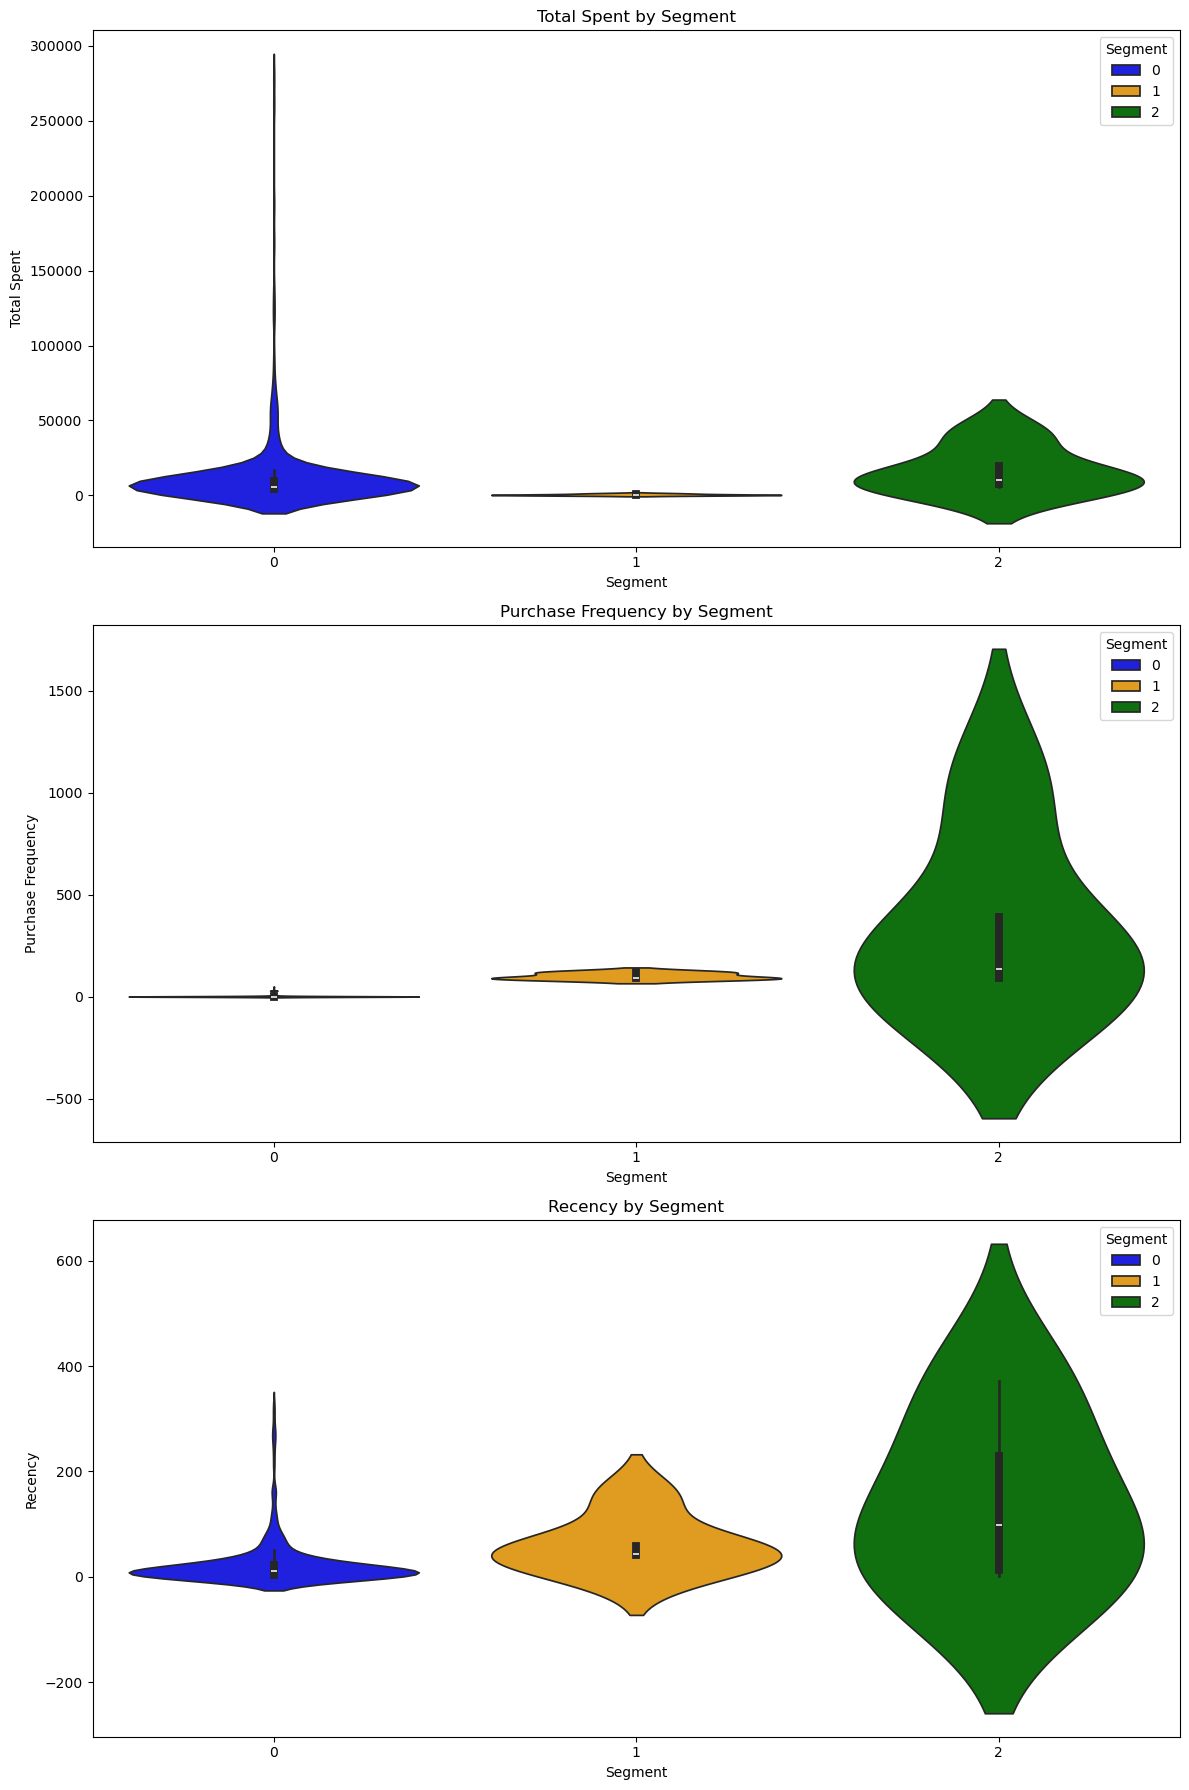

In [25]:
cluster_colors = {
  0: 'blue',
  1: 'orange',
  2: 'green'
}

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x='Segment', y='TotalSpent', data=outliers_segment_df, palette=cluster_colors, hue='Segment')
plt.title('Total Spent by Segment')
plt.ylabel('Total Spent')

plt.subplot(3, 1, 2)
sns.violinplot(x='Segment', y='PurchaseFrequency', data=outliers_segment_df, palette=cluster_colors, hue='Segment')
plt.title('Purchase Frequency by Segment')
plt.ylabel('Purchase Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x='Segment', y='Recency', data=outliers_segment_df, palette=cluster_colors, hue='Segment')
plt.title('Recency by Segment')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

### Adding Segment Lables

In [26]:
cluster_labels = {
  0: 'Pamper',
  1: 'Upsell',
  2: 'Delight'
}

outliers_segment_df['Segment'] = outliers_segment_df['Segment'].map(cluster_labels)
outliers_segment_df.head()

,TotalSpent,OrderCount,FirstInvoiceDate,LastInvoiceDate,CustomerLifespan,Recency,PurchaseFrequency,Segment
CustomerID,,,,,,,,
12346.0,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00,1,325,30.00,Pamper
12347.0,4310.00,7,2010-12-07 14:57:00,2011-12-07 15:52:00,365,1,0.58,Pamper
12357.0,6207.67,1,2011-11-06 16:07:00,2011-11-06 16:07:00,1,32,30.00,Pamper
12359.0,6372.58,4,2011-01-12 12:43:00,2011-10-13 12:47:00,274,57,0.44,Pamper
12362.0,4737.23,10,2011-02-17 10:30:00,2011-12-06 15:40:00,292,2,1.03,Pamper


### Exporting Data

In [27]:
outliers_segment_df.to_csv('../data/processed/customer_metrics_outliers.csv')